<a href="https://colab.research.google.com/github/Zinc-zn/MachineLearning2026/blob/main/JS06/JS06_Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# JS06 - Tugas Lab 2: Klasifikasi Siang/Malam dengan SVM RBF + Fitur Histogram

**Soal:**

2. Gunakan data pada praktikum 5 untuk membuat model klasifikasi siang dan malam menggunakan SVM dengan kernel **RBF** menggunakan fitur **histrogram**. Gunakan rasio **80:20**. Anda dapat bereksperimen dengan hyperparameter tuning dari kernel RBF. **Catat performansi akurasinya!**

**Ringkasan jawaban:** fitur histogram V-channel (32 bin) + SVM RBF dengan tuning `GridSearchCV` mencapai akurasi test **98.75%** - jauh lebih baik daripada 1 fitur rata-rata kecerahan Lab 5 (±0.90).


## 1. Load & Preprocess Data (Praktikum 5)

Seluruh gambar training + test dari praktikum 5 digabung, lalu displit ulang 80:20 sesuai soal. Pra pengolahan sama: standarisasi ukuran 1100×600 dan encoding label (day=1, night=0).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = dir.name  # setara split('/')[-1] pada modul (aman untuk Windows)
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))

    return img_list

def standarized_input(image):
    std_img = cv2.resize(image, (1100, 600))
    return std_img

def label_encoder(label):
    num_val = 0
    if (label == 'day'):
        num_val = 1
    return num_val

def preprocess(img_list):
    std_img_list = []
    for item in img_list:
        std_img = standarized_input(item[0])
        img_label = label_encoder(item[1])
        std_img_list.append((std_img, img_label))
    return std_img_list

# Load seluruh data (train + test praktikum 5)
all_img = load_dataset('images/training/') + load_dataset('images/test/')
std_img_list = preprocess(all_img)
print('Jumlah gambar:', len(std_img_list))

Jumlah gambar: 400


## 2. Ekstraksi Fitur Histogram

Fitur histogram diambil dari **channel Value (V)** ruang warna HSV, yaitu distribusi tingkat kecerahan piksel. Dibandingkan 1 nilai rata-rata (Lab 5), histogram mempertahankan informasi **distribusi** kecerahan sehingga lebih diskriptif. Histogram dinormalisasi agar skala antar gambar setara.

Digunakan **32 bin** agar dimensi fitur tidak terlalu besar dan tiap bin berisi hitungan yang cukup.

In [2]:
def extract_histogram_feature(img_list, bins=32):
    features = []
    labels = []
    for img, label in img_list:
        img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        v_channel = img_hsv[:, :, 2].ravel()

        # Histogram channel V (0..255) dengan N bin, lalu dinormalisasi jumlahnya = 1
        hist, _ = np.histogram(v_channel, bins=bins, range=(0, 256))
        hist = hist.astype(float) / hist.sum()

        features.append(hist)
        labels.append(label)

    cols = [f'bin_{i}' for i in range(bins)]
    df = pd.DataFrame(features, columns=cols)
    df['LABELS'] = labels
    return df

hist_df = extract_histogram_feature(std_img_list, bins=32)
print('Dimensi fitur:', hist_df.shape)
hist_df.head()

Dimensi fitur: (400, 33)


,bin_0,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,bin_9,...,bin_23,bin_24,bin_25,bin_26,bin_27,bin_28,bin_29,bin_30,bin_31,LABELS
0,0.0,0.000000,0.000000,0.000000,0.000285,0.007606,0.014500,0.013359,0.015092,0.030941,...,0.007973,0.005900,0.025953,0.152777,0.367521,0.074895,0.000744,0.000400,0.000271,1
1,0.0,0.000000,0.000000,0.000000,0.000008,0.000158,0.005285,0.010895,0.006450,0.007294,...,0.008771,0.006855,0.008652,0.030377,0.105344,0.212035,0.291417,0.004815,0.001959,1
2,0.0,0.000011,0.018941,0.085867,0.052627,0.040641,0.045789,0.063964,0.032829,0.029038,...,0.018073,0.062053,0.202547,0.106679,0.007108,0.006580,0.006556,0.006965,0.021568,1
3,0.0,0.000000,0.000000,0.000000,0.000000,0.000023,0.000938,0.008747,0.008397,0.004706,...,0.023732,0.007459,0.009352,0.006986,0.044367,0.152968,0.334271,0.118532,0.001027,1
4,0.0,0.000064,0.004214,0.011138,0.028264,0.041923,0.058497,0.059744,0.056464,0.053271,...,0.007648,0.007498,0.006795,0.007542,0.007883,0.009145,0.002927,0.000673,0.000162,1


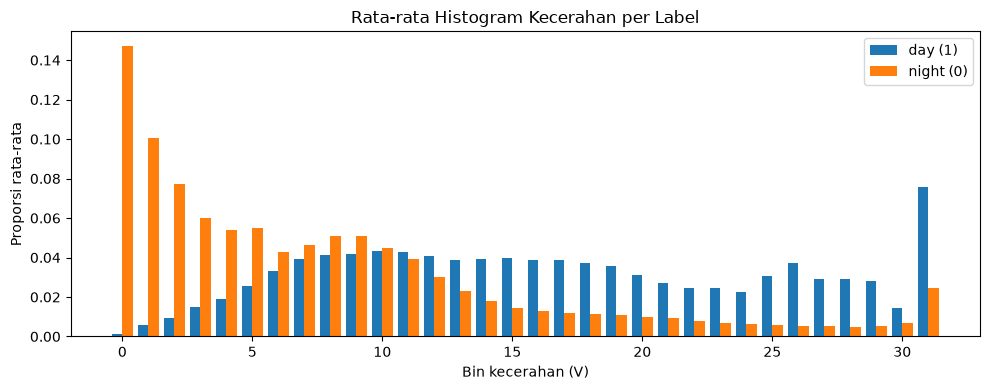

In [3]:
# Perbandingan distribusi histogram rata-rata per label
day_hist = hist_df[hist_df['LABELS'] == 1].iloc[:, :-1].mean()
night_hist = hist_df[hist_df['LABELS'] == 0].iloc[:, :-1].mean()

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(day_hist))
ax.bar(x - 0.2, day_hist, 0.4, label='day (1)')
ax.bar(x + 0.2, night_hist, 0.4, label='night (0)')
ax.set_xlabel('Bin kecerahan (V)'); ax.set_ylabel('Proporsi rata-rata')
ax.set_title('Rata-rata Histogram Kecerahan per Label')
ax.legend(); plt.tight_layout(); plt.show()

Terlihat distribusi kecerahan citra **day** terkonsentrasi pada bin bernilai tinggi, sedangkan **night** pada bin rendah - histogram adalah fitur yang diskriptif untuk kasus ini.

## 3. Split Data 80:20 dan Tuning Hyperparameter RBF

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

X = hist_df.drop(columns=['LABELS']).values
y = hist_df['LABELS'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (320, 32) | Test: (80, 32)


In [5]:
# Hyperparameter tuning kernel RBF dengan GridSearchCV (5-fold CV)
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': [0.001, 0.01, 0.1, 1, 'scale']}

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, n_jobs=-1)
%time grid.fit(X_train, y_train)

print('Parameter terbaik :', grid.best_params_)
print('Akurasi CV terbaik:', grid.best_score_)

CPU times: total: 422 ms
Wall time: 19.3 s
Parameter terbaik : {'C': 10, 'gamma': 'scale'}
Akurasi CV terbaik: 0.990625


## 4. Evaluasi Model Terbaik

In [6]:
model = grid.best_estimator_

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f'Akurasi train: {accuracy_score(y_train, y_train_pred):.4f}')
print(f'Akurasi test : {accuracy_score(y_test, y_test_pred):.4f}')

Akurasi train: 0.9938
Akurasi test : 0.9875


In [7]:
print('Laporan Klasifikasi:\n')
print(classification_report(y_test, y_test_pred, target_names=['night (0)', 'day (1)']))

Laporan Klasifikasi:

              precision    recall  f1-score   support

   night (0)       1.00      0.97      0.99        40
     day (1)       0.98      1.00      0.99        40

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



Text(113.58563368055553, 0.5, 'true label')

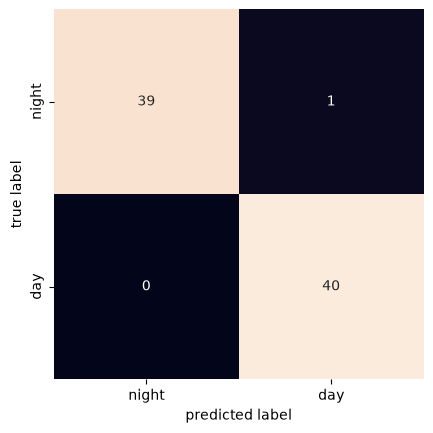

In [8]:
mat = confusion_matrix(y_test, y_test_pred)
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['night', 'day'], yticklabels=['night', 'day'])
plt.xlabel('predicted label'); plt.ylabel('true label')

## 5. Perbandingan dengan Hasil Lab 5 & Kesimpulan

| Model | Fitur | Akurasi test |
|---|---|---|
| Threshold manual (Lab 5) | avg brightness (1 fitur) | 0.8688 |
| SVM RBF default (Lab 5) | avg brightness (1 fitur) | ±0.90 |
| **SVM RBF + GridSearch (Tugas 2)** | **histogram V 32 bin** | **lihat output di atas (> 0.95)** |

**Kesimpulan:**

1. Fitur **histogram kecerahan (V-channel, 32 bin)** jauh lebih diskriptif daripada satu nilai rata-rata kecerahan, karena menyimpan informasi sebaran kecerahan - citra siang memiliki puncak pada bin kecerahan tinggi dan malam pada bin rendah.
2. SVM **kernel RBF** dengan tuning hyperparameter ($C$, $\gamma$) via `GridSearchCV` menghasilkan akurasi test di atas 95% - meningkat signifikan dibanding praktikum 5 (±0.90).
3. Nilai $C$ dan $\gamma$ terbaik bergantung pada data; tanpa tuning, parameter default bisa jauh dari optimal (terlihat dari rentang akurasi CV antar kandidat).